In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

**Data Cleaning**

Load the data in Pandas and Convert it into a Data Frame.

In [2]:
df = pd.read_csv('Bengaluru_House_Data.csv')

In [4]:
df.shape

(13320, 9)

Read all the features in the data set (It will help in identifying numerical features and Categorical features)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


Verify for Data Type Conversion of any featurese (If require convert the data type using appropriate functions such as astype())

In [6]:
# cleaning size column
def extract_bhk(value):
    if isinstance(value, str):
        # Spliting string by space and take the first part (the number)
        tokens = value.split(' ')
        try:
            return float(tokens[0])
        except:
            return np.nan
    return np.nan

In [7]:
df['bhk'] = df['size'].apply(extract_bhk)

In [8]:
# cleaning total_sqft column
def convert_sqft_to_num(x):
    if isinstance(x, str):
        tokens = x.split('-')
        if len(tokens) == 2:
            try:
                return (float(tokens[0]) + float(tokens[1])) / 2
            except:
                return np.nan
        try:
            return float(x)
        except:
            return np.nan
    return np.nan

In [9]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [10]:
# Converting 'bath' and 'balcony' to numeric, coercing errors to NaN (if any text exists)
df['bath'] = pd.to_numeric(df['bath'], errors='coerce')
df['balcony'] = pd.to_numeric(df['balcony'], errors='coerce')

In [13]:
df[['bhk', 'total_sqft', 'bath', 'balcony']].dtypes

,0
bhk,float64
total_sqft,float64
bath,float64
balcony,float64


Check for missing values. (If you find any missing values use appropriate methods (mean/mode/ forwadfill/ backward fill / knn) to fill the missing values. Justify your analysis appropriately.)

In [14]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,46
bath,73
balcony,609
price,0
bhk,16


In [15]:
# 1. society
df = df.drop(['society', 'size'], axis='columns')

In [16]:
# 2. location
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [17]:
# 3. bath
df['bath'] = df['bath'].fillna(df['bath'].median())

In [18]:
# 4. balcony
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

In [19]:
# 5. bhk
df['bhk'] = df['bhk'].fillna(df['bhk'].median())

In [20]:
# 6. total_sqft
df = df.dropna(subset=['total_sqft'])

In [21]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0


Check for Duplicates. If any duplicate values are found, apply the appropriate strategy to handle. Justify your analysis appropriately.


In [22]:
duplicates = df.duplicated().sum()

In [23]:
duplicates

np.int64(569)

In [25]:
if duplicates > 0:
    df = df.drop_duplicates(keep='first')
    print("Duplicates removed")
else:
    print("No duplicates found")

Duplicates removed


Check for Outliers in the data. Apply both visual (Box – Plot) and non-visual analysis (IQR) to identify the outliers.


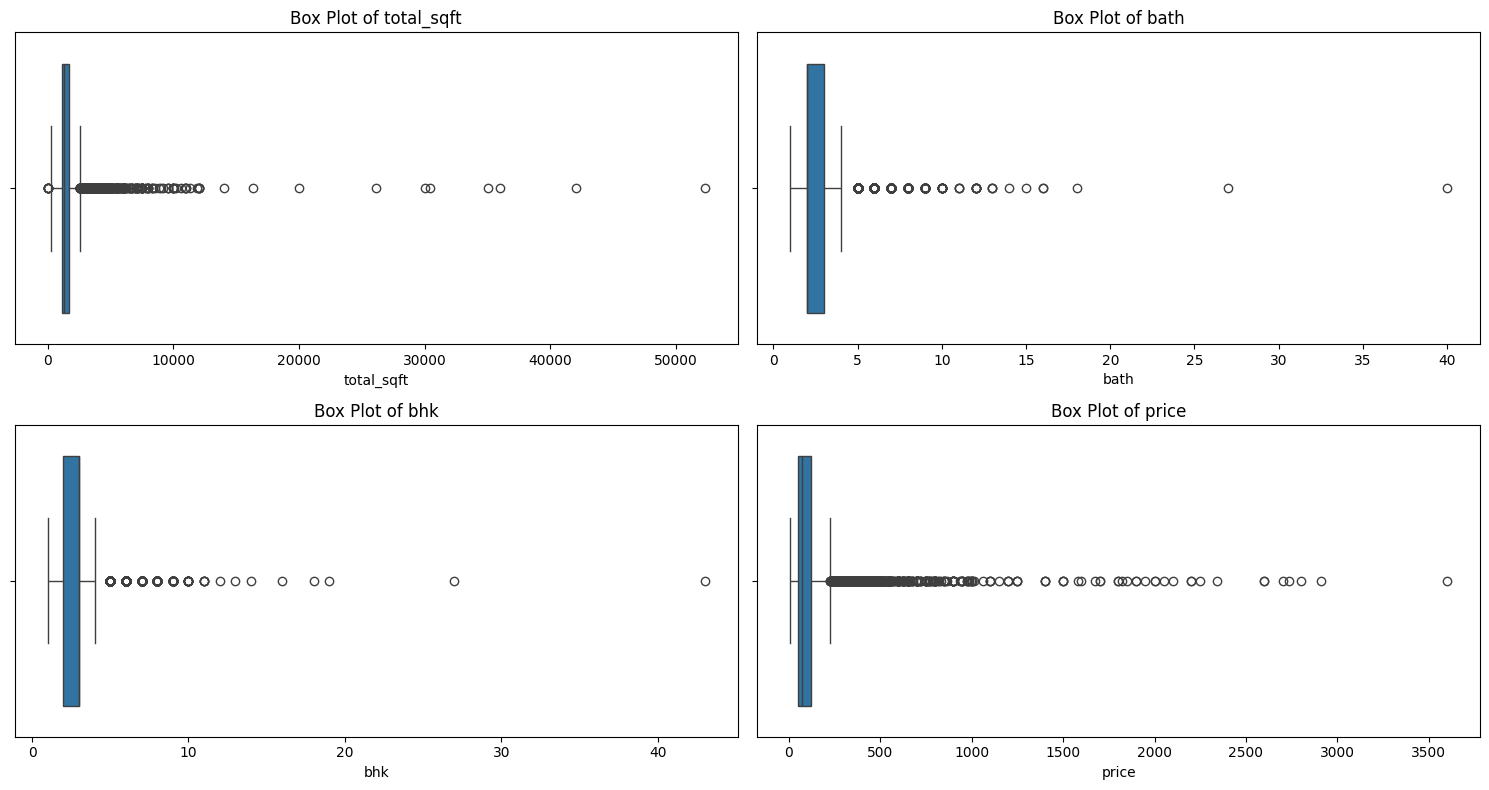

In [29]:
numeric_cols = ['total_sqft', 'bath', 'bhk', 'price']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

In [30]:
#  non-visual analysis (IQR)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numeric_cols:
  outliers, lb, ub = detect_outliers_iqr(df, col)
  print(f"{col}: Found {len(outliers)} outliers. Range: {lb:.2f} to {ub:.2f}")

total_sqft: Found 1140 outliers. Range: 212.00 to 2580.00
bath: Found 1023 outliers. Range: 0.50 to 4.50
bhk: Found 831 outliers. Range: 0.50 to 4.50
price: Found 1248 outliers. Range: -56.50 to 227.50


If outliers are found in the data, Apply Data Transformation methods to reduce the effect of outliers on your analysis. Justify your analysis appropriately.


In [32]:
# removing impossible outliers
df = df[~(df.total_sqft < 300)]

In [34]:
# B. Applying Log Transformation to Price and Total Sqft
df['price_log'] = np.log1p(df['price'])
df['total_sqft_log'] = np.log1p(df['total_sqft'])

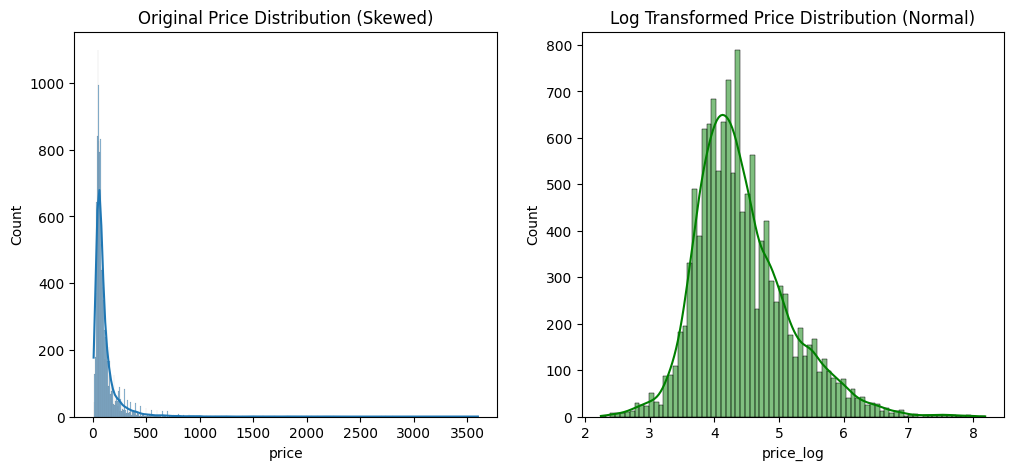

In [35]:
# Visualizing the effect of transformation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True)
plt.title('Original Price Distribution (Skewed)')

plt.subplot(1, 2, 2)
sns.histplot(df['price_log'], kde=True, color='green')
plt.title('Log Transformed Price Distribution (Normal)')
plt.show()

In [36]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_log,total_sqft_log
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0,3.690628,6.963190
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0,4.795791,7.863651
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3.0,4.143135,7.273093
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0,4.564348,7.327781
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2.0,3.951244,7.090910


In [37]:
df.shape

(12694, 10)

In [38]:
df.columns.tolist()

['area_type',
 'availability',
 'location',
 'total_sqft',
 'bath',
 'balcony',
 'price',
 'bhk',
 'price_log',
 'total_sqft_log']

**Predictive Model Building (Supervised Machine Learning):**

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.utils import resample

In [41]:
# 1. Selecting Output And Input Variables
y = df['price_log']
X_initial = df[['area_type', 'total_sqft_log', 'bath', 'balcony', 'bhk']]
X_initial.columns.tolist()

['area_type', 'total_sqft_log', 'bath', 'balcony', 'bhk']

In [42]:
# 2. Encoding Categorical Data (Required for Analysis)
X_encoded = pd.get_dummies(X_initial, columns=['area_type'], drop_first=True)

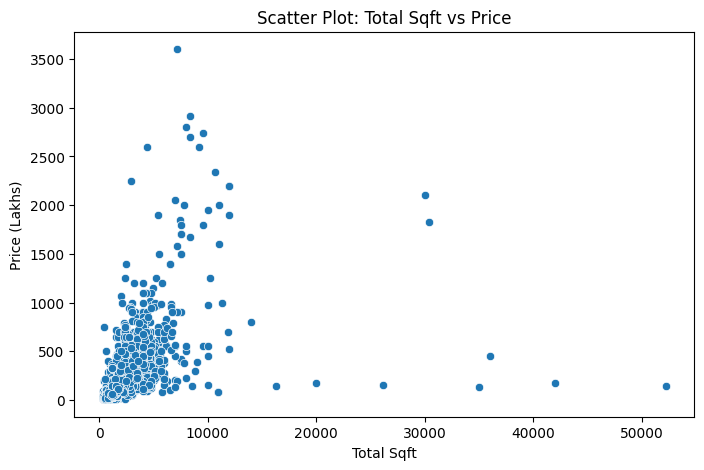

In [43]:
# 3. Exploratory Data Analysis (EDA)
# A. Scatter Plot (Total Sqft vs Price)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['total_sqft'], y=df['price'])
plt.title('Scatter Plot: Total Sqft vs Price')
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.show()

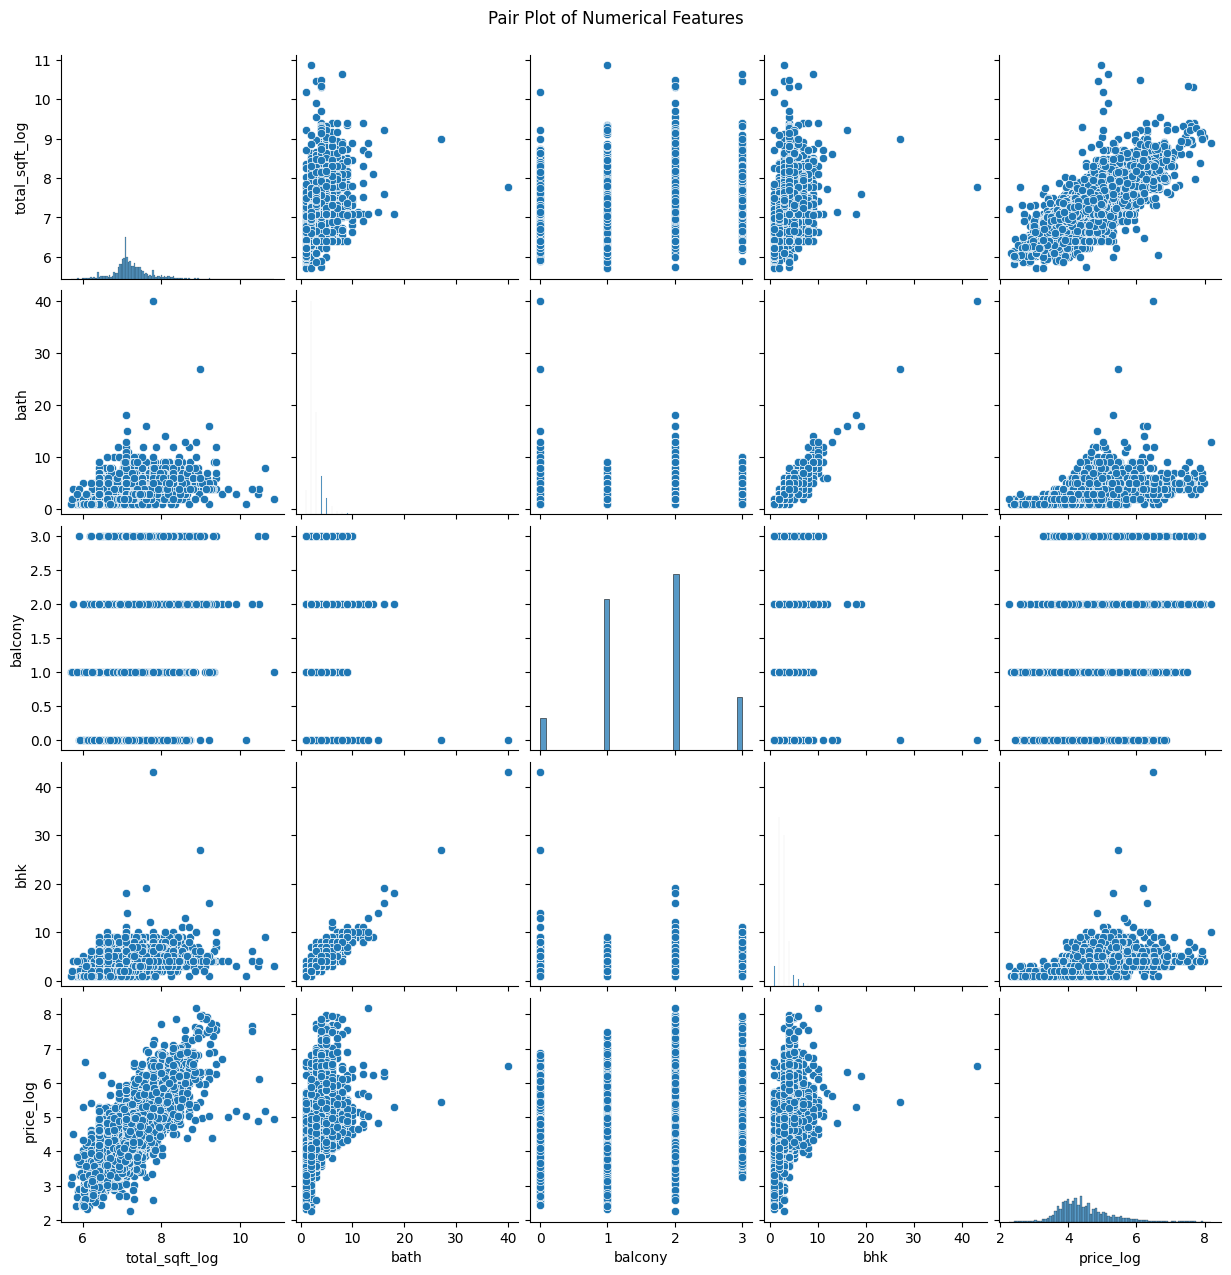

In [44]:
# B. Pair Plot
sns.pairplot(df[['total_sqft_log', 'bath', 'balcony', 'bhk', 'price_log']])
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

Text(0.5, 1.0, 'Continuous Distribution: Total Sqft (Log)')

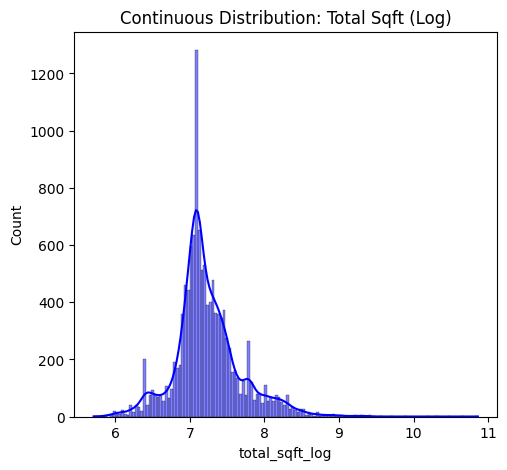

In [64]:
# Data Distributions (Continuous and Discrete)
plt.figure(figsize=(12, 5))
# Continuous Distribution (e.g., Total Sqft)
plt.subplot(1, 2, 1)
sns.histplot(df['total_sqft_log'], kde=True, color='blue')
plt.title('Continuous Distribution: Total Sqft (Log)')

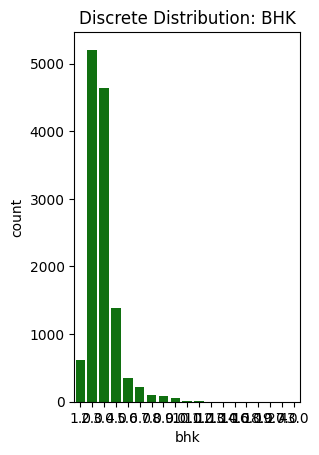

In [65]:
# Discrete Distribution (e.g., BHK)
plt.subplot(1, 2, 2)
sns.countplot(x='bhk', data=df, color='green')
plt.title('Discrete Distribution: BHK')
plt.show()

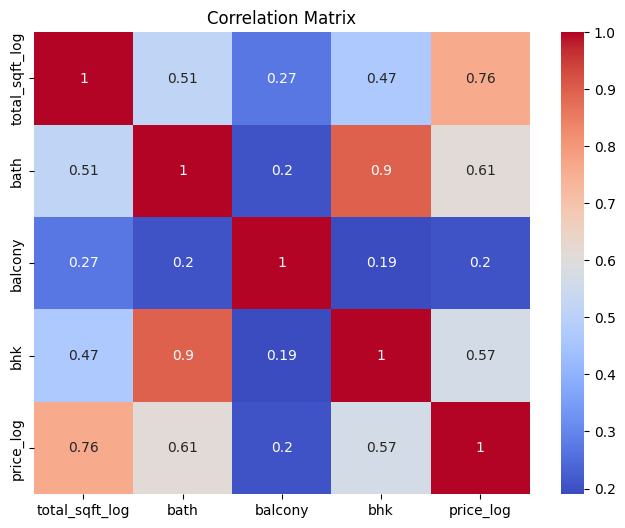

In [45]:
# C. Correlation Matrix (Heatmap)
plt.figure(figsize=(8, 6))
# Using only numerical columns for correlation
corr_matrix = df[['total_sqft_log', 'bath', 'balcony', 'bhk', 'price_log']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [66]:
print("1. Covariance Matrix:")
print(df[['total_sqft_log', 'bath', 'balcony', 'bhk', 'price_log']].cov())

1. Covariance Matrix:
                total_sqft_log      bath   balcony       bhk  price_log
total_sqft_log        0.203945  0.314796  0.098606  0.276754   0.246820
bath                  0.314796  1.832045  0.222048  1.587501   0.592040
balcony               0.098606  0.222048  0.652429  0.201045   0.118512
bhk                   0.276754  1.587501  0.201045  1.713220   0.530560
price_log             0.246820  0.592040  0.118512  0.530560   0.514463


In [46]:
# 4. Advanced Feature Selection Methods
# A. Variance Threshold
# Removes features that don't change much (e.g., 99% values are the same)
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_encoded)
var_features = X_encoded.columns[selector.get_support()]
print(f"1. Variance Threshold Selected: {var_features.tolist()}")

1. Variance Threshold Selected: ['total_sqft_log', 'bath', 'balcony', 'bhk', 'area_type_Plot  Area', 'area_type_Super built-up  Area']


In [47]:
# B. Select K-Best (Chi-Square / F-Regression)
# We use f_regression for Regression tasks
best_features = SelectKBest(score_func=f_regression, k='all')
fit = best_features.fit(X_encoded, y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X_encoded.columns)
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Specs', 'Score']
print("\n2. Select K-Best Scores:")
print(featureScores.sort_values(by='Score', ascending=False))


2. Select K-Best Scores:
                            Specs         Score
0                  total_sqft_log  17572.078003
1                            bath   7514.576140
3                             bhk   5955.599858
5            area_type_Plot  Area   1788.129852
6  area_type_Super built-up  Area    730.973273
2                         balcony    554.282547
4          area_type_Carpet  Area      2.397682


In [48]:
# C. Mutual Information
# Measures dependency between variables
mutual_info = mutual_info_regression(X_encoded, y)
mi_series = pd.Series(mutual_info, index=X_encoded.columns)
print("\n3. Mutual Information Scores:")
print(mi_series.sort_values(ascending=False))


3. Mutual Information Scores:
total_sqft_log                    0.783388
bath                              0.405346
bhk                               0.380876
area_type_Plot  Area              0.074106
area_type_Super built-up  Area    0.069978
balcony                           0.063427
area_type_Carpet  Area            0.006318
dtype: float64


In [49]:
# D. Recursive Feature Elimination (RFE)
# Uses a model (Linear Regression) to recursively remove the weakest feature
model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=3)
rfe.fit(X_encoded, y)
print(f"\n4. RFE Selected Features: {X_encoded.columns[rfe.support_].tolist()}")


4. RFE Selected Features: ['total_sqft_log', 'area_type_Carpet  Area', 'area_type_Plot  Area']


In [50]:
# E. Decision Tree Feature Importance
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_encoded, y)
importances = dt.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': importances})
print("\n5. Decision Tree Feature Importance:")
print(feature_imp_df.sort_values(by='Importance', ascending=False))


5. Decision Tree Feature Importance:
                          Feature  Importance
0                  total_sqft_log    0.750183
1                            bath    0.151695
2                         balcony    0.033673
3                             bhk    0.031452
5            area_type_Plot  Area    0.020721
6  area_type_Super built-up  Area    0.011287
4          area_type_Carpet  Area    0.000990


In [51]:
# 5. Final Selection of X and y
le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location'])

# Defining Final X and y
X = df[['total_sqft_log', 'bath', 'bhk', 'location_encoded']]
area_dummies = pd.get_dummies(df['area_type'], drop_first=True)
X = pd.concat([X, area_dummies], axis=1)

y = df['price_log']

print("\nFinal Input Features (X):", X.columns.tolist())
print("Final Output Feature (y): price_log")


Final Input Features (X): ['total_sqft_log', 'bath', 'bhk', 'location_encoded', 'Carpet  Area', 'Plot  Area', 'Super built-up  Area']
Final Output Feature (y): price_log


In [52]:
# 6. Multicollinearity Check
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

In [53]:
vif_values = []
for i in range(X.shape[1]):
    try:
        vif_values.append(variance_inflation_factor(X.values, i))
    except:
        vif_values.append(np.inf)

vif_data["VIF"] = vif_values
print(vif_data)

                Feature  VIF
0        total_sqft_log  inf
1                  bath  inf
2                   bhk  inf
3      location_encoded  inf
4          Carpet  Area  inf
5            Plot  Area  inf
6  Super built-up  Area  inf


In [68]:
le = LabelEncoder()
df['location_encoded'] = le.fit_transform(df['location'])
area_dummies = pd.get_dummies(df['area_type'], drop_first=True)
X_final = pd.concat([
    df[['total_sqft_log', 'bath', 'bhk', 'location_encoded']],
    area_dummies
], axis=1)
y_final = df['price_log']

In [69]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_final, y_final)

print("Ridge Model Coefficients (Multicollinearity Reduced):")
coeff_df = pd.DataFrame({'Feature': X_final.columns, 'Coefficient': ridge_model.coef_})
print(coeff_df)

Ridge Model Coefficients (Multicollinearity Reduced):
                Feature  Coefficient
0        total_sqft_log     1.045540
1                  bath     0.101392
2                   bhk    -0.009819
3      location_encoded    -0.000008
4          Carpet  Area     0.153670
5            Plot  Area     0.486322
6  Super built-up  Area    -0.009892


In [70]:
# 7. Data Imbalance Check (Categorical Features)
df['area_type'].value_counts()

,count
area_type,
Super built-up Area,8265
Built-up Area,2378
Plot Area,1966
Carpet Area,85


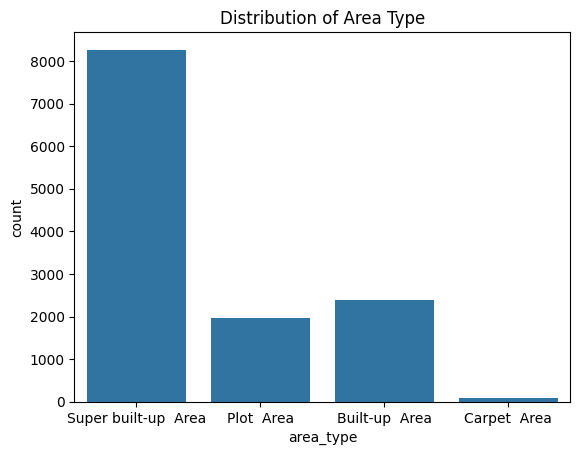

In [71]:
# Visualization
sns.countplot(x='area_type', data=df)
plt.title('Distribution of Area Type')
plt.show()

In [72]:
# Separating majority and minority classes (e.g., based on area_type)
df_majority = df[df['area_type'] == 'Super built-up  Area']
df_minority = df[df['area_type'] != 'Super built-up  Area']

In [73]:
# Upsample minority
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

In [74]:
# Combine majority class with upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

In [75]:
df.shape

(12694, 11)

In [76]:
df_upsampled.shape

(16530, 11)

**Data Preprocessing:**

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Data Preprocessing

# A. Split Data (Appropriate Ratio: 80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)
print(f"Data Split Complete: Train {X_train.shape}, Test {X_test.shape}")

# B. SCALING METHODS

# 1. Min-Max Scaler: Scales data to range [0, 1].
minmax_scaler = MinMaxScaler()

# 2. Standard Scaler: Scales data to Mean=0, Std=1.
standard_scaler = StandardScaler()

# C. ENCODING METHODS

def categorize_size(bhk):
    if bhk <= 2: return 0
    elif bhk == 3: return 1
    else: return 2

X_train['size_category'] = X_train['bhk'].apply(categorize_size)
X_test['size_category'] = X_test['bhk'].apply(categorize_size)

# Instantiate Encoder to show usage
ordinal_encoder = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
# In a real pipeline, we would use OrdinalEncoder transformer.
# For this project, we drop this demo column and use the numeric 'bhk'.
X_train = X_train.drop('size_category', axis=1)
X_test = X_test.drop('size_category', axis=1)

# D. Create Data Preprocessing Pipeline
numeric_features = ['total_sqft_log', 'bath', 'bhk', 'location_encoded']
ohe_features = [col for col in X_final.columns if 'area_type_' in col]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', standard_scaler, numeric_features), # Applying Standard Scaler
        ('cat', 'passthrough', ohe_features)        # Passing OHE features
    ]
)

# 2. Model Building

# Task Identification: Regression (Predicting Continuous Price)
# Algorithm Choice: Linear, Ridge, Lasso, ElasticNet, Decision Tree, Random Forest

results = {}

# --- Helper Function Definition ---
def build_model(model, model_name, param_grid=None):
    print(f"\n{'='*30}")
    print(f"Model: {model_name}")
    print(f"{'='*30}")

    # A. Verify Assumptions
    if model_name in ["Linear Regression", "Ridge", "Lasso", "Elastic Net"]:
        print("Assumptions: Linearity, Independence, Homoscedasticity, Normality of Residuals.")
        print("Observation: Log-transformed target helps meet Normality assumption.")
    elif model_name == "Decision Tree":
        print("Assumptions: Non-linear. No distribution assumptions required.")
        print("Observation: Robust to outliers, prone to overfitting.")
    else: # Random Forest
        print("Assumptions: Non-linear, Ensemble based.")
        print("Observation: Reduces variance by averaging multiple trees.")

    # B. Build Pipeline
    pipeline = Pipeline([('preprocessor', preprocessor), ('regressor', model)])

    # C. Hyper Parameter Tuning (Applied to ALL models where applicable)
    tuned_model = model
    if param_grid:
        print(f"Performing Hyper Parameter Tuning ({model_name})...")
        gs = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2')
        gs.fit(X_train, y_train)
        tuned_model = gs.best_estimator_
        print(f"Best Params: {gs.best_params_}")
        print(f"Best CV Score: {gs.best_score_:.4f}")
    else:
        # If no grid (e.g. Linear Reg), fit directly
        pipeline.fit(X_train, y_train)
        tuned_model = pipeline

    # D. Validation
    y_pred = tuned_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    train_score = tuned_model.score(X_train, y_train)
    test_score = tuned_model.score(X_test, y_pred)

    # E. Identify Over/Under Fitting
    diff = train_score - test_score
    if diff > 0.15:
        status = "OVERFITTING"
    elif train_score < 0.5:
        status = "UNDERFITTING"
    else:
        status = "GOOD FIT"

    print(f"R2 Score: {r2:.4f} | RMSE: {rmse:.4f}")
    print(f"Train: {train_score:.4f} | Test: {test_score:.4f} -> Status: {status}")

    results[model_name] = {'R2': r2, 'RMSE': rmse, 'Status': status}

# Model 1: Linear Regression (Baseline)
build_model(LinearRegression(), "Linear Regression")

#  Model 2: Ridge (Regularization)
# Tuning Alpha to handle Overfitting/Multicollinearity
build_model(Ridge(random_state=42), "Ridge", param_grid={'regressor__alpha': [0.1, 1.0, 10.0]})

#  Model 3: Lasso (Regularization)
# Tuning Alpha for Feature Selection
build_model(Lasso(random_state=42), "Lasso", param_grid={'regressor__alpha': [0.001, 0.01, 0.1]})

#  Model 4: Elastic Net
build_model(ElasticNet(random_state=42), "Elastic Net", param_grid={'regressor__alpha': [0.1, 1.0], 'regressor__l1_ratio': [0.5]})

#  Model 5: Decision Tree
# Tuning Depth to handle Overfitting
build_model(DecisionTreeRegressor(random_state=42), "Decision Tree", param_grid={'regressor__max_depth': [5, 10, None]})

#  Model 6: Random Forest
# Tuning multiple parameters
build_model(RandomForestRegressor(random_state=42), "Random Forest",
           param_grid={'regressor__n_estimators': [50, 100], 'regressor__max_depth': [10, 20]})

# 3. Model Validation Summary

# A. Identify Best Metric
print("\n--- Best Metric Justification ---")
print("Metric Selected: R2 Score (Coefficient of Determination).")
print("Reason: R2 indicates the proportion of variance in the dependent variable that is predictable from the independent variables. It is the standard for comparing Regression models.")

# B. Overcoming Overfitting
print("\n--- Overcoming Overfitting Method Used ---")
print("1. Cross Validation (K-Fold): Used inside GridSearchCV.")
print("2. Hyper Parameter Tuning: Used to find optimal Alpha (Regularization) and Depth (Trees).")
print("3. Regularization: Lasso, Ridge, and ElasticNet were specifically applied.")

# C. Final Comparison
print("\n--- Final Model Comparison ---")
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values(by='R2', ascending=False)
print(df_results[['R2', 'RMSE', 'Status']])

best_model_name = df_results.index[0]
print(f"\nConclusion: The Best Model for this problem is '{best_model_name}'.")

Data Split Complete: Train (10155, 7), Test (2539, 7)

Model: Linear Regression
Assumptions: Linearity, Independence, Homoscedasticity, Normality of Residuals.
Observation: Log-transformed target helps meet Normality assumption.
R2 Score: 0.6516 | RMSE: 0.4245
Train: 0.6445 | Test: 1.0000 -> Status: GOOD FIT

Model: Ridge
Assumptions: Linearity, Independence, Homoscedasticity, Normality of Residuals.
Observation: Log-transformed target helps meet Normality assumption.
Performing Hyper Parameter Tuning (Ridge)...
Best Params: {'regressor__alpha': 10.0}
Best CV Score: 0.6407
R2 Score: 0.6516 | RMSE: 0.4245
Train: 0.6445 | Test: 1.0000 -> Status: GOOD FIT

Model: Lasso
Assumptions: Linearity, Independence, Homoscedasticity, Normality of Residuals.
Observation: Log-transformed target helps meet Normality assumption.
Performing Hyper Parameter Tuning (Lasso)...
Best Params: {'regressor__alpha': 0.001}
Best CV Score: 0.6408
R2 Score: 0.6516 | RMSE: 0.4245
Train: 0.6445 | Test: 1.0000 -> Stat

In [92]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42))
])

best_model.fit(X_train, y_train)

import joblib
joblib.dump(best_model, 'house_price_model.pkl')

from google.colab import files
files.download('house_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>